# Series de Tiempo — Modelado completo (AR, MA, ARMA, ARIMA, SARIMA)

**Curso:** CC3084 · **Semestre 02, 2026**

Este cuaderno acompaña la presentación *Series de Tiempo*. Trabajamos un flujo completo de
análisis de series de tiempo sobre un conjunto de datos de uso libre:

1. Carga y análisis exploratorio (EDA).
2. Verificación de los supuestos (estacionariedad con ADF y KPSS).
3. Transformaciones para lograr estacionariedad (logaritmo y diferenciación).
4. Lectura de ACF y PACF para proponer los órdenes p y q.
5. Construcción de **todos** los modelos: AR, MA, ARMA, ARIMA y SARIMA.
6. Validación de **todos** los modelos (diagnóstico de residuos, Ljung-Box y error fuera de muestra).
7. Comparación y **selección del mejor modelo** para este caso.
8. Validación walk-forward y pronóstico final con intervalos de confianza.

**Conjunto de datos:** *Air Passengers* — total mensual de pasajeros de aerolíneas
internacionales (1949–1960). Es un clásico de dominio público, ideal porque tiene
tendencia y estacionalidad multiplicativa muy marcadas.

## 0. Instalación de dependencias

Si te falta alguna librería, descomenta y ejecuta la siguiente celda.

In [30]:
# !pip install numpy pandas matplotlib scipy statsmodels scikit-learn

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(suppress=True)

## 1. Carga de datos

Incrustamos los 144 valores mensuales para que el cuaderno funcione sin conexión.
Construimos un índice de fechas mensual (`freq='MS'`, inicio de mes).

In [58]:
valores = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
]

idx = pd.date_range("1949-01-01", periods=len(valores), freq="MS")
serie = pd.Series(valores, index=idx, name="pasajeros")

print("Observaciones:", len(serie))
print("Rango:", serie.index.min().date(), "->", serie.index.max().date())
serie.head(20)

Observaciones: 144
Rango: 1949-01-01 -> 1960-12-01


1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
1950-08-01    170
Freq: MS, Name: pasajeros, dtype: int64

## 2. Análisis exploratorio (EDA)

Antes de modelar, miramos la serie desde varios ángulos.

### 2.1 La serie en el tiempo

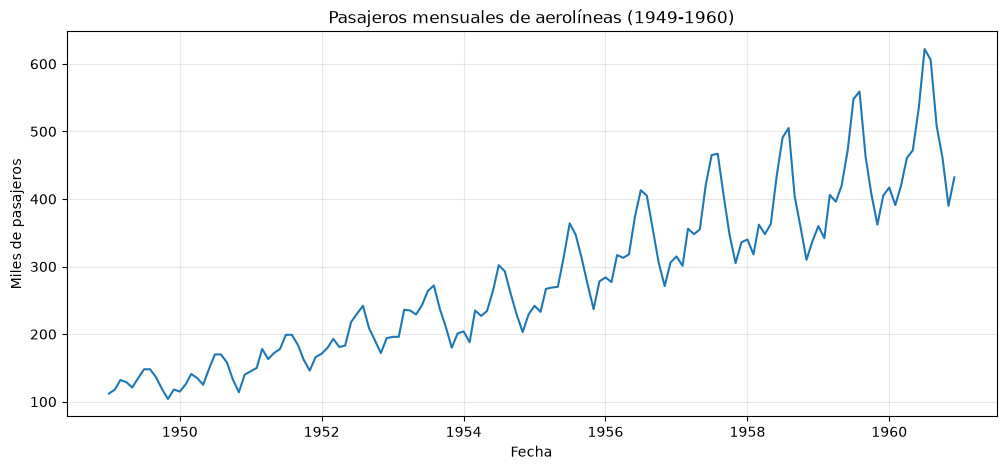

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: pasajeros, dtype: float64

In [33]:
plt.figure()
plt.plot(serie, color="#1f77b4")
plt.title("Pasajeros mensuales de aerolíneas (1949-1960)")
plt.xlabel("Fecha"); plt.ylabel("Miles de pasajeros")
plt.show()

serie.describe()

Se aprecian dos rasgos claros: una **tendencia** creciente y una **estacionalidad**
cuya amplitud crece con el nivel de la serie (indicio de estacionalidad *multiplicativa*).

### 2.2 Media y desviación móviles

Si la media y la varianza cambian con el tiempo, la serie **no** es estacionaria.

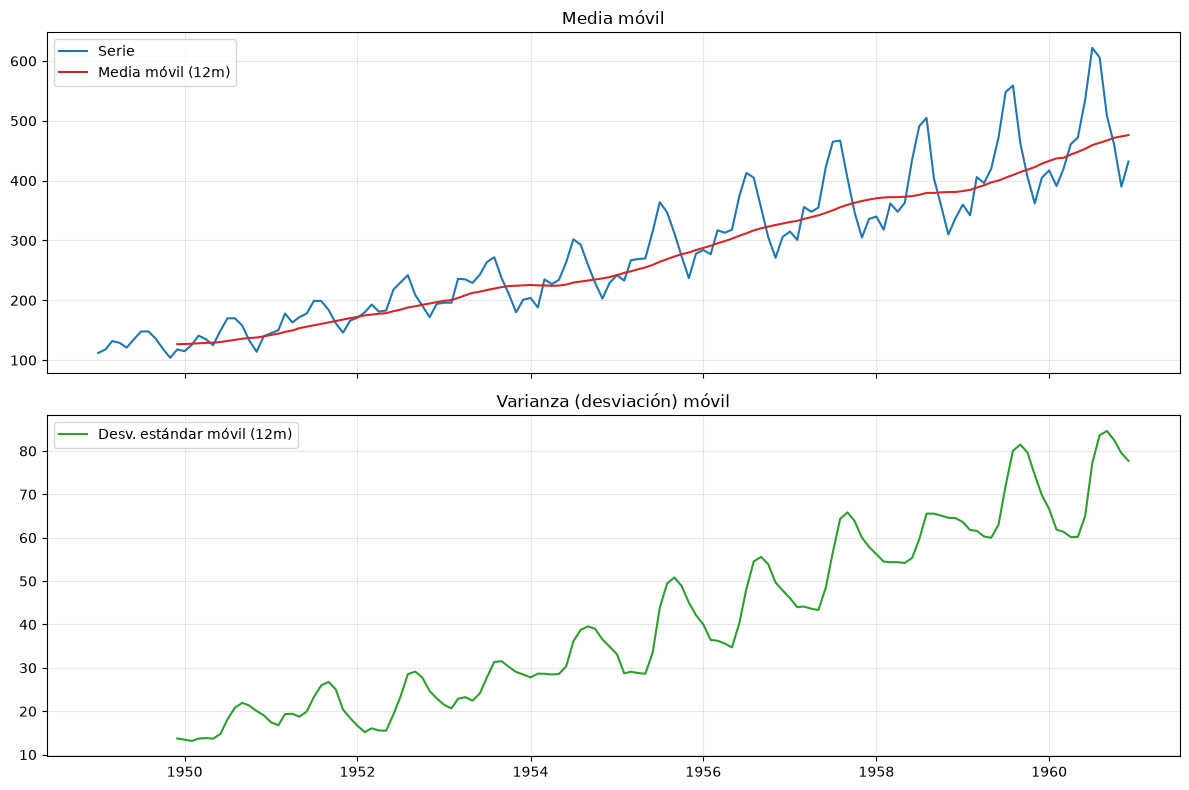

In [34]:
ventana = 12
media_movil = serie.rolling(ventana).mean()
std_movil = serie.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(serie, label="Serie", color="#1f77b4")
ax[0].plot(media_movil, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil"); ax[0].legend()

ax[1].plot(std_movil, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil"); ax[1].legend()
plt.tight_layout(); plt.show()

Tanto la media como la desviación móvil suben: confirma tendencia y varianza creciente.

### 2.3 Estacionalidad: patrón por mes y por año

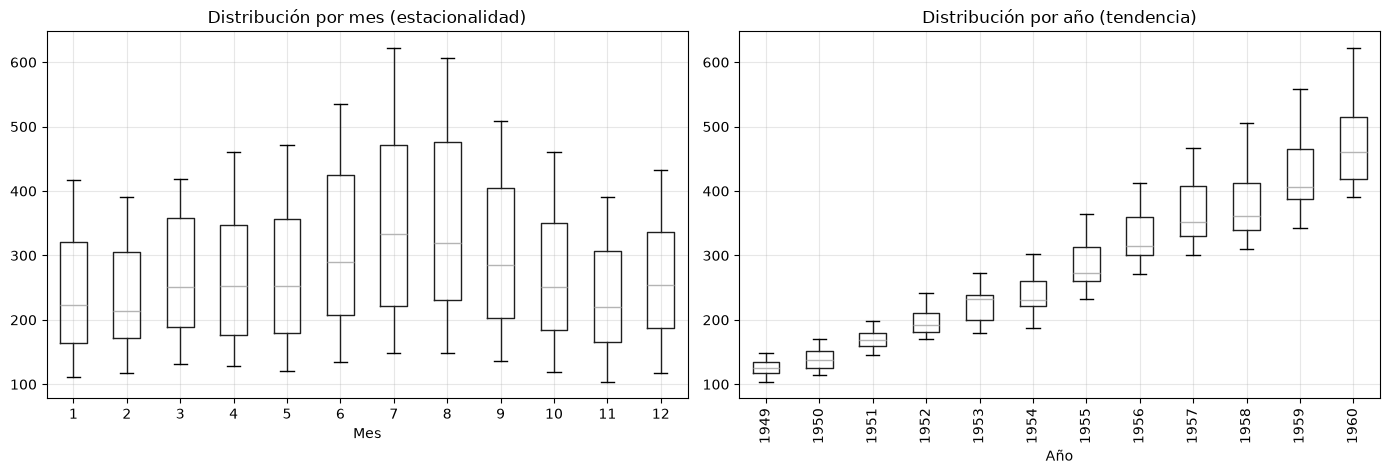

In [35]:
df = serie.to_frame()
df["mes"] = df.index.month
df["anio"] = df.index.year

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column="pasajeros", by="mes", ax=ax[0])
ax[0].set_title("Distribución por mes (estacionalidad)"); ax[0].set_xlabel("Mes")
df.boxplot(column="pasajeros", by="anio", ax=ax[1])
ax[1].set_title("Distribución por año (tendencia)"); ax[1].set_xlabel("Año")
ax[1].tick_params(axis="x", rotation=90)
plt.suptitle(""); plt.tight_layout(); plt.show()

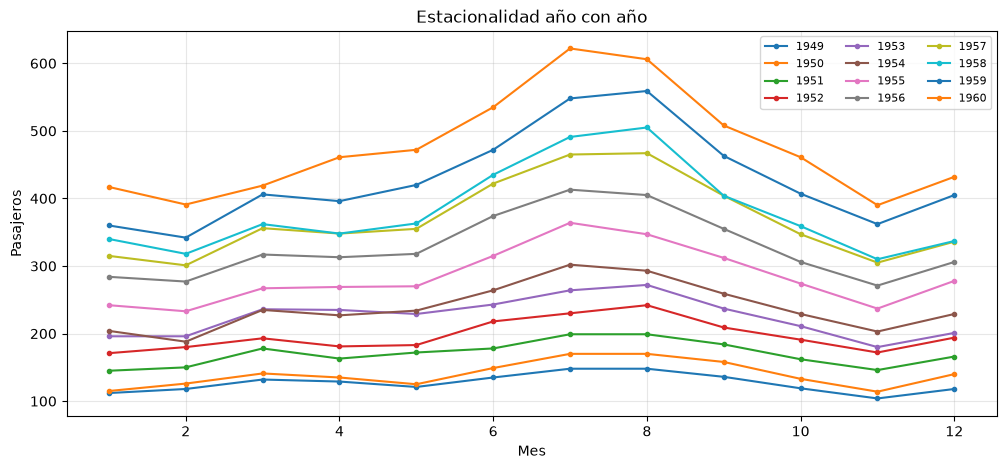

In [36]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df.pivot_table(index="mes", columns="anio", values="pasajeros")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

### 2.4 Descomposición aditiva y multiplicativa

Separamos la serie en tendencia + estacionalidad + residuo. Comparamos los dos modelos:
la **multiplicativa** debería dejar un residuo más plano cuando la amplitud estacional
crece con el nivel.

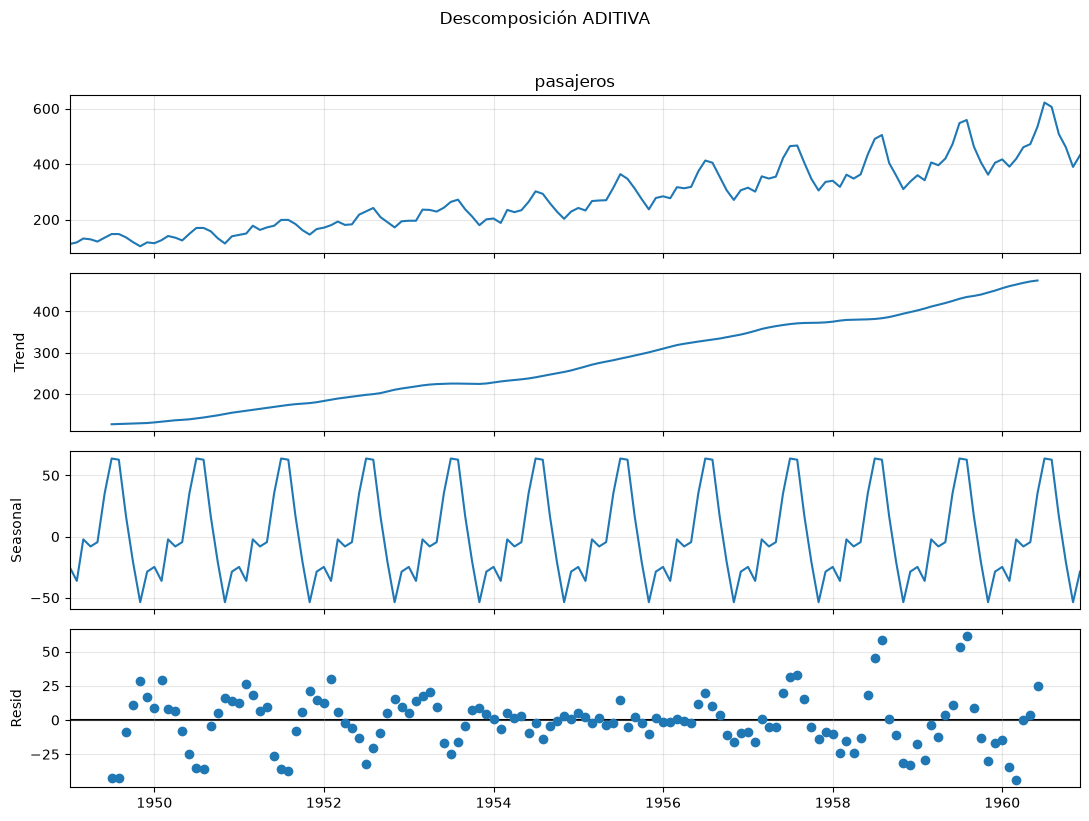

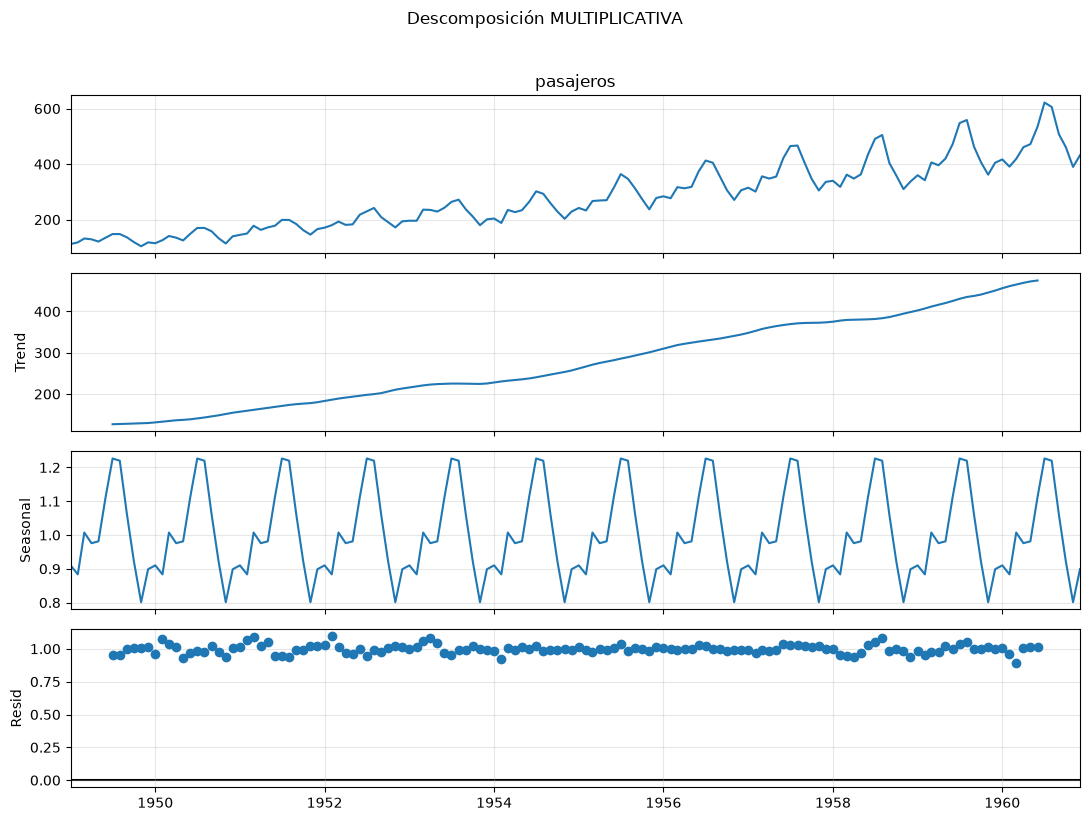

Desv. estándar del residuo (aditiva):     19.3405
Desv. estándar del residuo (multiplicativa): 0.0334


In [37]:
desc_add = seasonal_decompose(serie, model="additive", period=12)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=12)

fig = desc_add.plot(); fig.set_size_inches(11, 8)
fig.suptitle("Descomposición ADITIVA", y=1.02); plt.tight_layout(); plt.show()

fig = desc_mul.plot(); fig.set_size_inches(11, 8)
fig.suptitle("Descomposición MULTIPLICATIVA", y=1.02); plt.tight_layout(); plt.show()

print("Desv. estándar del residuo (aditiva):     %.4f" % desc_add.resid.std())
print("Desv. estándar del residuo (multiplicativa): %.4f" % desc_mul.resid.std())

El residuo de la descomposición multiplicativa es más estable, lo que sugiere trabajar
con el **logaritmo** de la serie para convertir la estacionalidad multiplicativa en aditiva.

## 3. Supuestos: prueba de estacionariedad

Los modelos AR, MA y ARMA suponen una serie **estacionaria**. Lo verificamos con dos pruebas
complementarias:

- **ADF** (Augmented Dickey-Fuller): H0 = la serie NO es estacionaria. Si p < 0.05 la
  consideramos estacionaria.
- **KPSS**: H0 = la serie ES estacionaria. Si p < 0.05 la consideramos NO estacionaria.

Usar ambas evita conclusiones erróneas: lo ideal es que ADF rechace su H0 y KPSS no rechace la suya.

In [38]:
def prueba_adf(x, nombre=""):
    r = adfuller(x.dropna(), autolag="AIC")
    veredicto = "estacionaria" if r[1] < 0.05 else "NO estacionaria"
    print(f"ADF  {nombre:<18} estadístico={r[0]:8.3f}  p-valor={r[1]:.4f}  ->  {veredicto}")

def prueba_kpss(x, nombre=""):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = kpss(x.dropna(), regression="c", nlags="auto")
    veredicto = "NO estacionaria" if r[1] < 0.05 else "estacionaria"
    print(f"KPSS {nombre:<18} estadístico={r[0]:8.3f}  p-valor={r[1]:.4f}  ->  {veredicto}")

print("=== Serie original ===")
prueba_adf(serie, "original")
prueba_kpss(serie, "original")

=== Serie original ===
ADF  original           estadístico=   0.815  p-valor=0.9919  ->  NO estacionaria
KPSS original           estadístico=   1.651  p-valor=0.0100  ->  NO estacionaria


### 3.1 Estabilizar la varianza: logaritmo

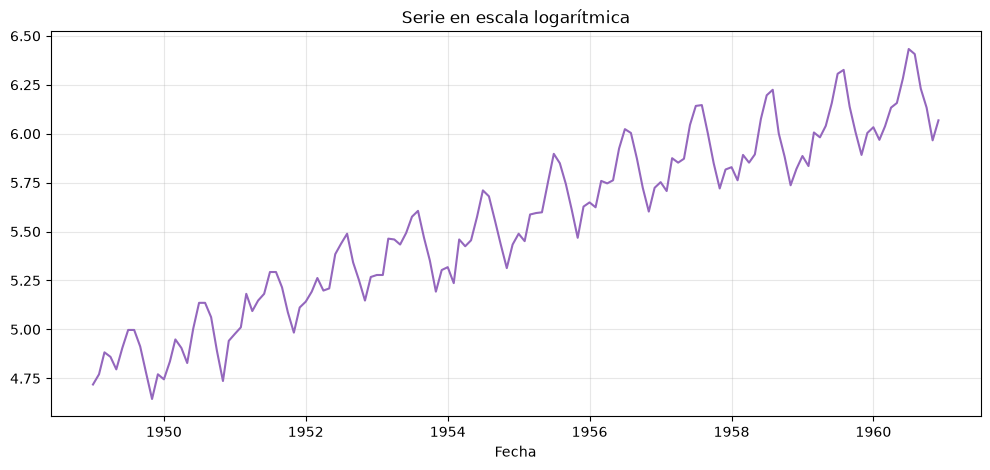

=== Serie log ===
ADF  log                estadístico=  -1.717  p-valor=0.4224  ->  NO estacionaria
KPSS log                estadístico=   1.669  p-valor=0.0100  ->  NO estacionaria


In [39]:
y_log = np.log(serie)

plt.figure()
plt.plot(y_log, color="#9467bd")
plt.title("Serie en escala logarítmica"); plt.xlabel("Fecha"); plt.show()

print("=== Serie log ===")
prueba_adf(y_log, "log")
prueba_kpss(y_log, "log")

El log estabiliza la varianza, pero sigue habiendo tendencia y estacionalidad: aún no es estacionaria.

### 3.2 Diferenciación regular y estacional

- Diferenciación regular `d=1`: elimina la tendencia.
- Diferenciación estacional `D=1` con período 12: elimina la estacionalidad anual.

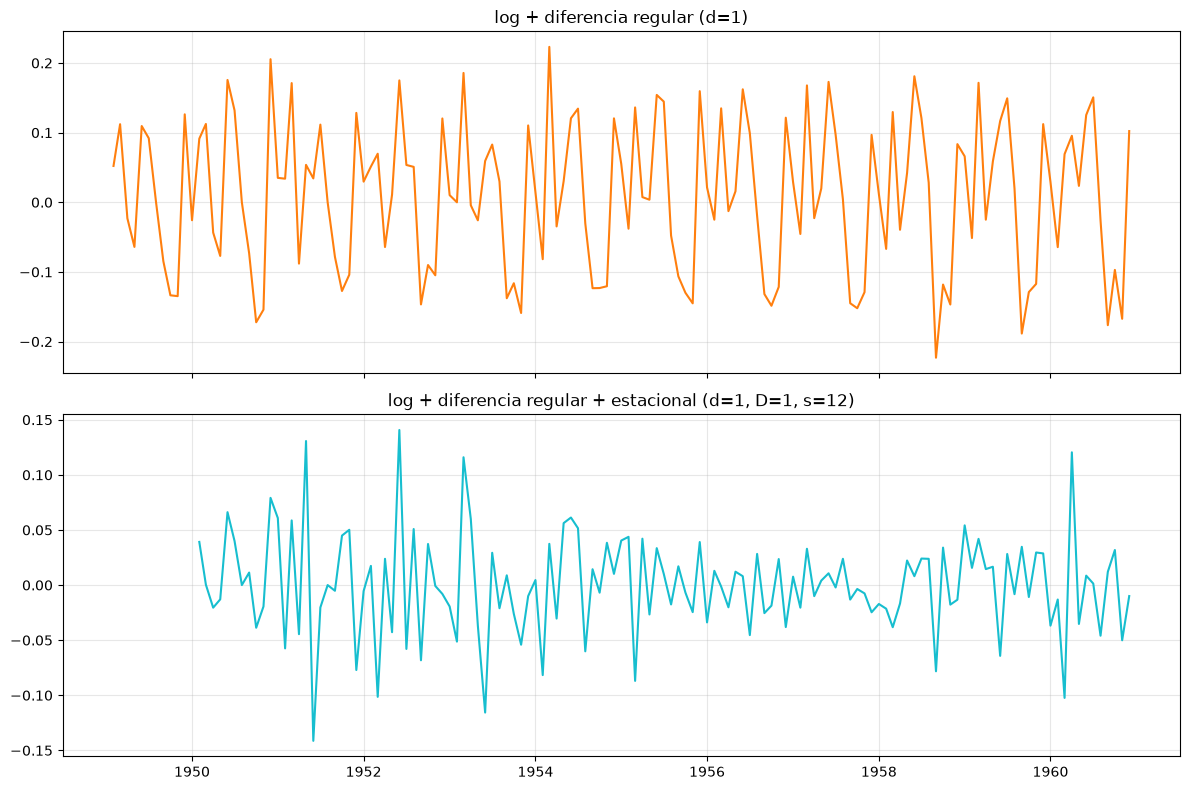

=== Solo diferencia regular ===
ADF  log d=1            estadístico=  -2.717  p-valor=0.0711  ->  NO estacionaria
KPSS log d=1            estadístico=   0.038  p-valor=0.1000  ->  estacionaria

=== Diferencia regular + estacional ===
ADF  log d=1 D=1        estadístico=  -4.443  p-valor=0.0002  ->  estacionaria
KPSS log d=1 D=1        estadístico=   0.073  p-valor=0.1000  ->  estacionaria


In [40]:
y_diff = y_log.diff(1).dropna()                 # quita tendencia
y_stat = y_log.diff(1).diff(12).dropna()        # quita tendencia + estacionalidad

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(y_diff, color="#ff7f0e"); ax[0].set_title("log + diferencia regular (d=1)")
ax[1].plot(y_stat, color="#17becf"); ax[1].set_title("log + diferencia regular + estacional (d=1, D=1, s=12)")
plt.tight_layout(); plt.show()

print("=== Solo diferencia regular ===")
prueba_adf(y_diff, "log d=1"); prueba_kpss(y_diff, "log d=1")
print("\n=== Diferencia regular + estacional ===")
prueba_adf(y_stat, "log d=1 D=1"); prueba_kpss(y_stat, "log d=1 D=1")

Tras la diferenciación regular la serie ya es estacionaria según ADF y KPSS.
La diferencia estacional adicional la usaremos en SARIMA. Concluimos: **d = 1** (y **D = 1** para la parte estacional).

## 4. ACF y PACF: proponer p y q

Sobre la serie estacionaria leemos las gráficas:

- **PACF** sugiere el orden **p** (parte AR): mira en qué lag se corta.
- **ACF** sugiere el orden **q** (parte MA): mira en qué lag se corta.

Los picos en los lags 12, 24, ... indican componente estacional.

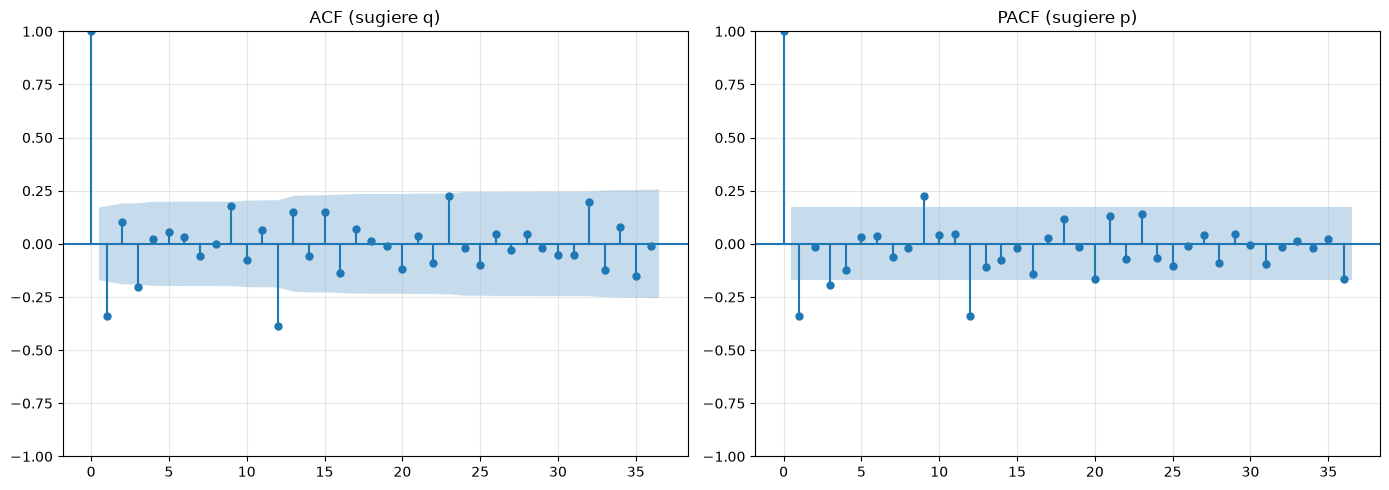

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(y_stat, lags=36, ax=ax[0])
ax[0].set_title("ACF (sugiere q)")
plot_pacf(y_stat, lags=36, ax=ax[1], method="ywm")
ax[1].set_title("PACF (sugiere p)")
plt.tight_layout(); plt.show()

Como punto de partida tomamos órdenes bajos (p, q ∈ {0,1,2}) y confirmamos con búsqueda por AIC.
Los picos estacionales en el lag 12 motivan P y Q estacionales de orden 1.

## 5. Partición temporal (train / test)

Reservamos los **últimos 24 meses** como conjunto de prueba. La prueba es siempre posterior
en el tiempo: nunca barajamos los datos.

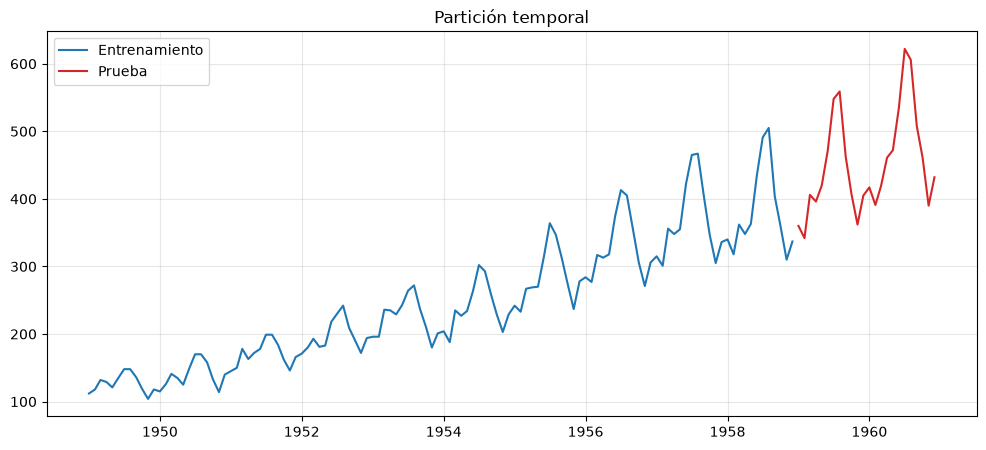

Train: 120  Test: 24


In [42]:
H = 24                       # horizonte de prueba (meses)
y = np.log(serie)            # modelamos en escala log; invertimos con exp al evaluar
train, test = y.iloc[:-H], y.iloc[-H:]
test_orig = np.exp(test)     # valores reales en escala original

plt.figure()
plt.plot(np.exp(train), label="Entrenamiento", color="#1f77b4")
plt.plot(np.exp(test), label="Prueba", color="#d62728")
plt.title("Partición temporal"); plt.legend(); plt.show()

print("Train:", len(train), " Test:", len(test))

## 6. Construcción de los modelos

Para pronosticar la serie original, cada familia se aplica con la diferenciación necesaria
(**d = 1**). Con la interfaz `SARIMAX` los órdenes quedan así:

| Familia | order | seasonal_order |
|---|---|---|
| AR(p)   | (p, 1, 0) | (0,0,0,0) |
| MA(q)   | (0, 1, q) | (0,0,0,0) |
| ARMA(p,q) | (p, 1, q) | (0,0,0,0) |
| ARIMA(p,d,q) | mejor por AIC | (0,0,0,0) |
| SARIMA | mejor por AIC | (P,D,Q,12) |

Definimos utilidades para ajustar, evaluar (MAE, RMSE, MAPE) e invertir el logaritmo.

In [43]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

def ajustar(order, seasonal_order=(0, 0, 0, 0)):
    mod = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
    return mod.fit(disp=False)

def evaluar(res):
    """Pronostica el horizonte de prueba y devuelve (pred_orig, mae, rmse, mape)."""
    fc = res.get_forecast(steps=H)
    pred = np.exp(fc.predicted_mean)
    mae, rmse, mape = metricas(test_orig.values, pred.values)
    return pred, mae, rmse, mape

resultados = {}   # nombre -> dict con modelo, pred y métricas

### 6.1 Modelo AR(p) — ARIMA(2,1,0)

                               SARIMAX Results                                
Dep. Variable:              pasajeros   No. Observations:                  120
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 100.320
Date:                Mon, 13 Jul 2026   AIC                           -194.641
Time:                        17:12:32   BIC                           -186.354
Sample:                    01-01-1949   HQIC                          -191.277
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
AIC=-194.64  MAE=105.09  RMSE=128.58  MAPE=21.30%


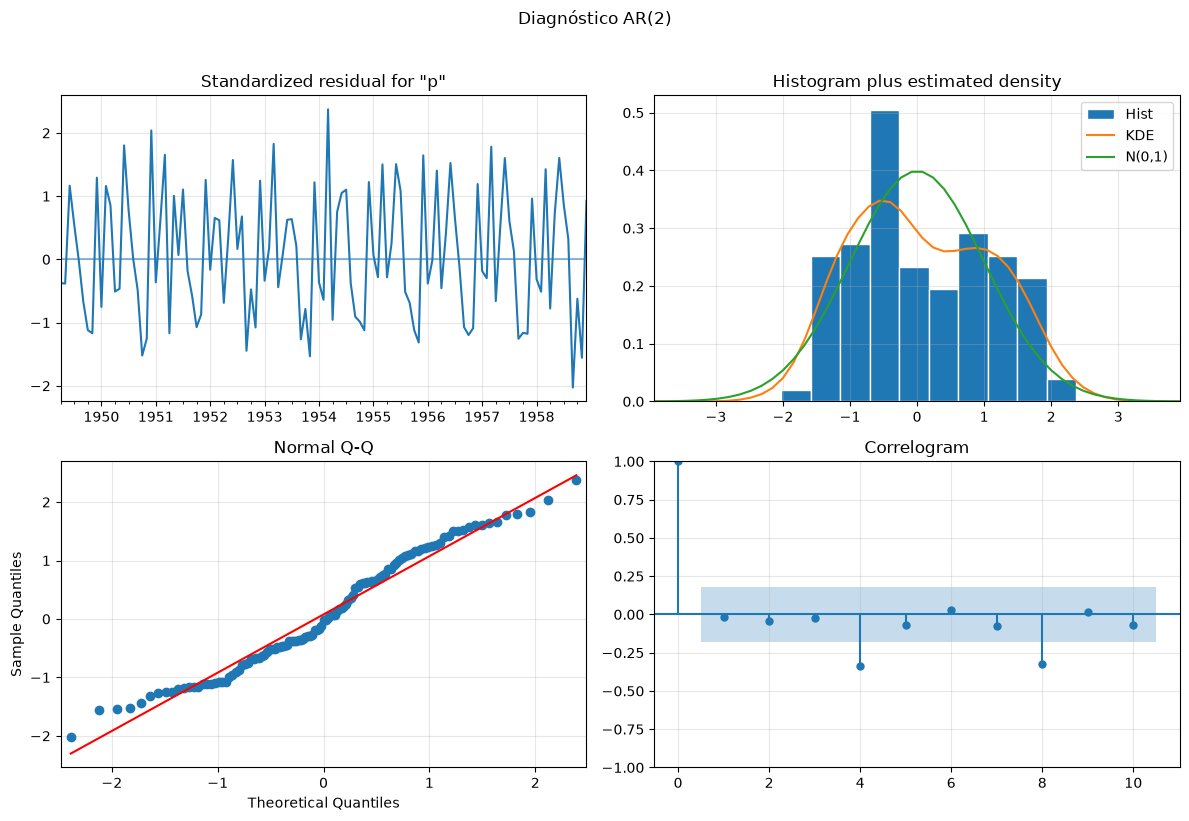

In [44]:
res_ar = ajustar((2, 1, 0))
pred_ar, mae, rmse, mape = evaluar(res_ar)
resultados["AR(2)"] = dict(res=res_ar, pred=pred_ar, aic=res_ar.aic, mae=mae, rmse=rmse, mape=mape)
print(res_ar.summary().tables[0])
print(f"AIC={res_ar.aic:.2f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
fig = res_ar.plot_diagnostics(figsize=(12, 8)); plt.suptitle("Diagnóstico AR(2)", y=1.02); plt.tight_layout(); plt.show()

### 6.2 Modelo MA(q) — ARIMA(0,1,2)

AIC=-194.02  MAE=99.56  RMSE=123.73  MAPE=20.08%


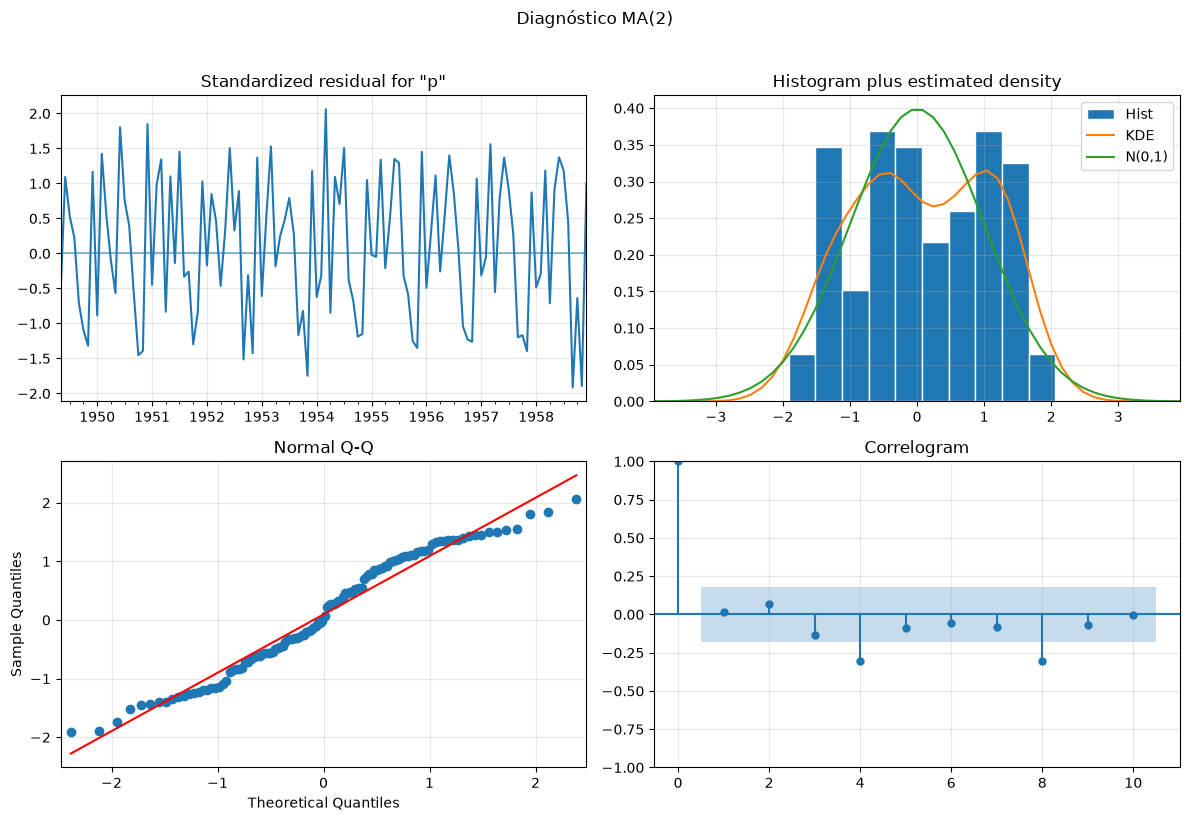

In [45]:
res_ma = ajustar((0, 1, 2))
pred_ma, mae, rmse, mape = evaluar(res_ma)
resultados["MA(2)"] = dict(res=res_ma, pred=pred_ma, aic=res_ma.aic, mae=mae, rmse=rmse, mape=mape)
print(f"AIC={res_ma.aic:.2f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
fig = res_ma.plot_diagnostics(figsize=(12, 8)); plt.suptitle("Diagnóstico MA(2)", y=1.02); plt.tight_layout(); plt.show()

### 6.3 Modelo ARMA(p,q) — ARIMA(2,1,2)

AIC=-198.07  MAE=87.04  RMSE=112.13  MAPE=17.38%


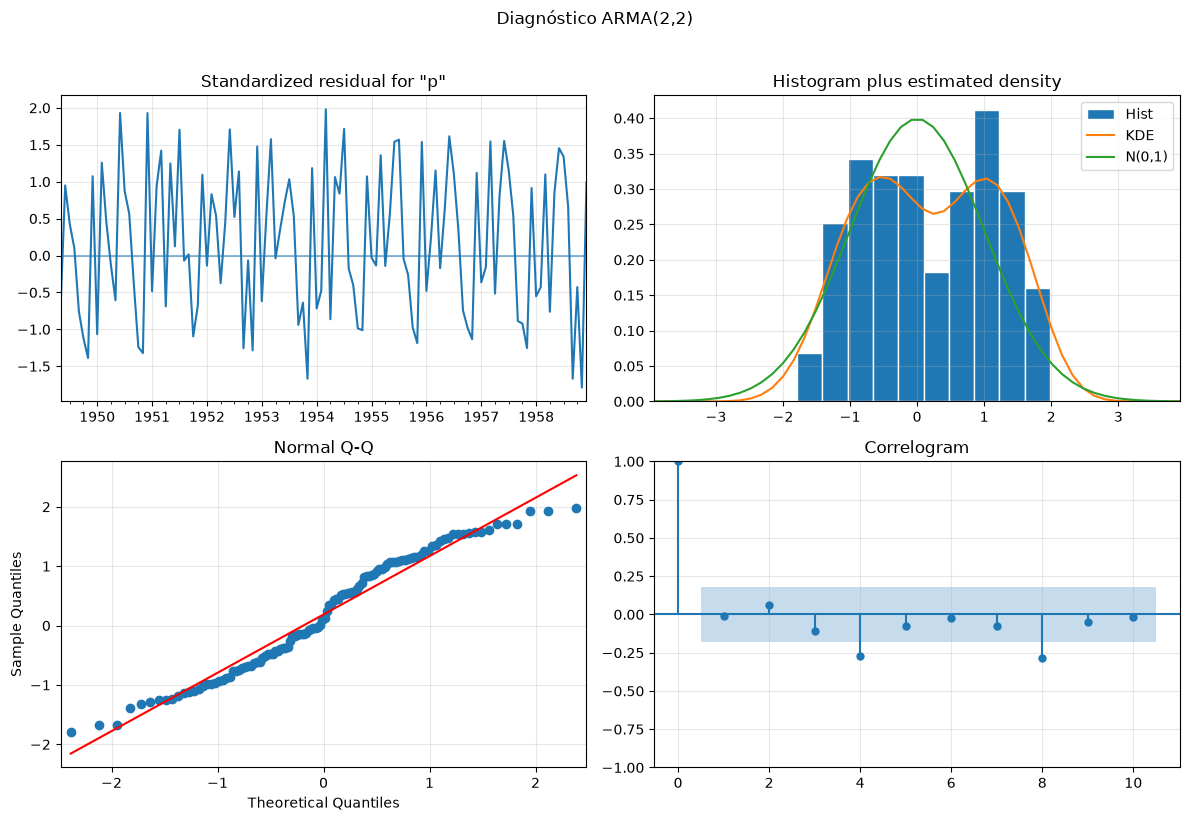

In [46]:
res_arma = ajustar((2, 1, 2))
pred_arma, mae, rmse, mape = evaluar(res_arma)
resultados["ARMA(2,2)"] = dict(res=res_arma, pred=pred_arma, aic=res_arma.aic, mae=mae, rmse=rmse, mape=mape)
print(f"AIC={res_arma.aic:.2f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
fig = res_arma.plot_diagnostics(figsize=(12, 8)); plt.suptitle("Diagnóstico ARMA(2,2)", y=1.02); plt.tight_layout(); plt.show()

### 6.4 Modelo ARIMA(p,d,q) — búsqueda por AIC

Recorremos combinaciones de p y q (con d = 1 fijo) y graficamos un **mapa de calor del AIC**
para ver cómo cambia según los parámetros.

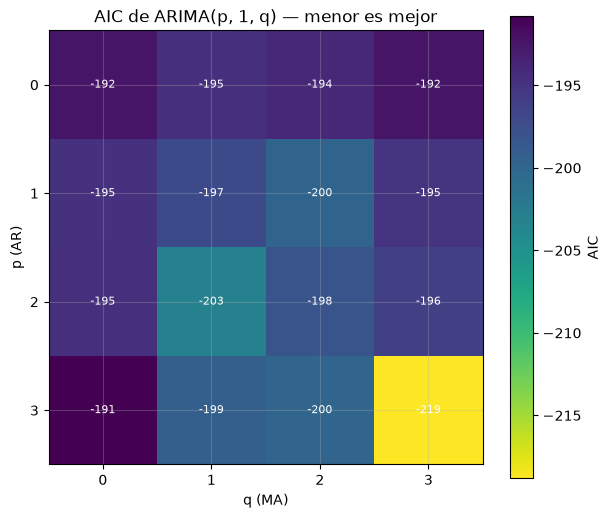

Mejor ARIMA por AIC: (3, 1, 3)  AIC=-218.83


In [47]:
import itertools

ps = range(0, 4)
qs = range(0, 4)
aic_matrix = np.full((len(list(ps)), len(list(qs))), np.nan)
ps = list(range(0, 4)); qs = list(range(0, 4))

for i, p in enumerate(ps):
    for j, q in enumerate(qs):
        try:
            r = ajustar((p, 1, q))
            aic_matrix[i, j] = r.aic
        except Exception:
            aic_matrix[i, j] = np.nan

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(aic_matrix, cmap="viridis_r")
ax.set_xticks(range(len(qs))); ax.set_xticklabels(qs)
ax.set_yticks(range(len(ps))); ax.set_yticklabels(ps)
ax.set_xlabel("q (MA)"); ax.set_ylabel("p (AR)")
ax.set_title("AIC de ARIMA(p, 1, q) — menor es mejor")
for i in range(len(ps)):
    for j in range(len(qs)):
        if not np.isnan(aic_matrix[i, j]):
            ax.text(j, i, f"{aic_matrix[i, j]:.0f}", ha="center", va="center", color="w", fontsize=8)
fig.colorbar(im, ax=ax, label="AIC")
plt.show()

bi, bj = np.unravel_index(np.nanargmin(aic_matrix), aic_matrix.shape)
best_arima_order = (ps[bi], 1, qs[bj])
print("Mejor ARIMA por AIC:", best_arima_order, " AIC=%.2f" % aic_matrix[bi, bj])

AIC=-218.83  MAE=44.55  RMSE=61.02  MAPE=9.00%


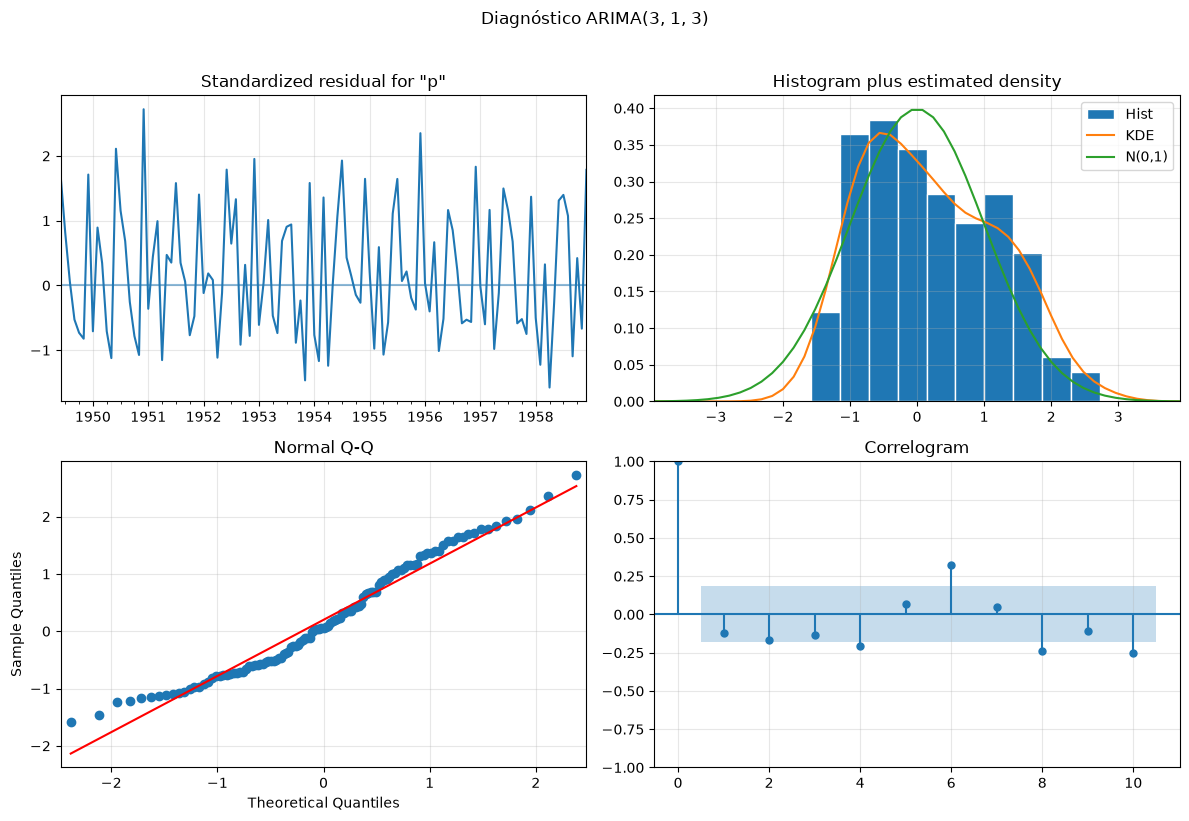

In [48]:
res_arima = ajustar(best_arima_order)
pred_arima, mae, rmse, mape = evaluar(res_arima)
resultados[f"ARIMA{best_arima_order}"] = dict(res=res_arima, pred=pred_arima, aic=res_arima.aic, mae=mae, rmse=rmse, mape=mape)
print(f"AIC={res_arima.aic:.2f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
fig = res_arima.plot_diagnostics(figsize=(12, 8)); plt.suptitle(f"Diagnóstico ARIMA{best_arima_order}", y=1.02); plt.tight_layout(); plt.show()

### 6.5 Modelo SARIMA — búsqueda por AIC

Añadimos la parte estacional (período 12). Buscamos sobre órdenes no estacionales
(p, q ∈ {0,1,2}) y estacionales (P, Q ∈ {0,1}), con d = 1 y D = 1.

In [49]:
mejor = {"aic": np.inf, "order": None, "sorder": None}
registro = []

for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):
                order = (p, 1, q)
                sorder = (P, 1, Q, 12)
                try:
                    r = ajustar(order, sorder)
                    registro.append((order, sorder, r.aic))
                    if r.aic < mejor["aic"]:
                        mejor = {"aic": r.aic, "order": order, "sorder": sorder}
                except Exception:
                    continue

registro.sort(key=lambda t: t[2])
print("Top 5 configuraciones SARIMA por AIC:")
for order, sorder, a in registro[:5]:
    print(f"  order={order} seasonal={sorder}  AIC={a:.2f}")

best_sarima_order = mejor["order"]
best_sarima_sorder = mejor["sorder"]
print("\nMejor SARIMA:", best_sarima_order, best_sarima_sorder, "AIC=%.2f" % mejor["aic"])

Top 5 configuraciones SARIMA por AIC:
  order=(1, 1, 0) seasonal=(0, 1, 0, 12)  AIC=-359.98
  order=(0, 1, 1) seasonal=(0, 1, 0, 12)  AIC=-356.40
  order=(1, 1, 1) seasonal=(0, 1, 0, 12)  AIC=-354.64
  order=(2, 1, 0) seasonal=(0, 1, 0, 12)  AIC=-353.65
  order=(2, 1, 2) seasonal=(0, 1, 0, 12)  AIC=-350.70

Mejor SARIMA: (1, 1, 0) (0, 1, 0, 12) AIC=-359.98


AIC=-359.98  MAE=67.63  RMSE=73.22  MAPE=14.73%


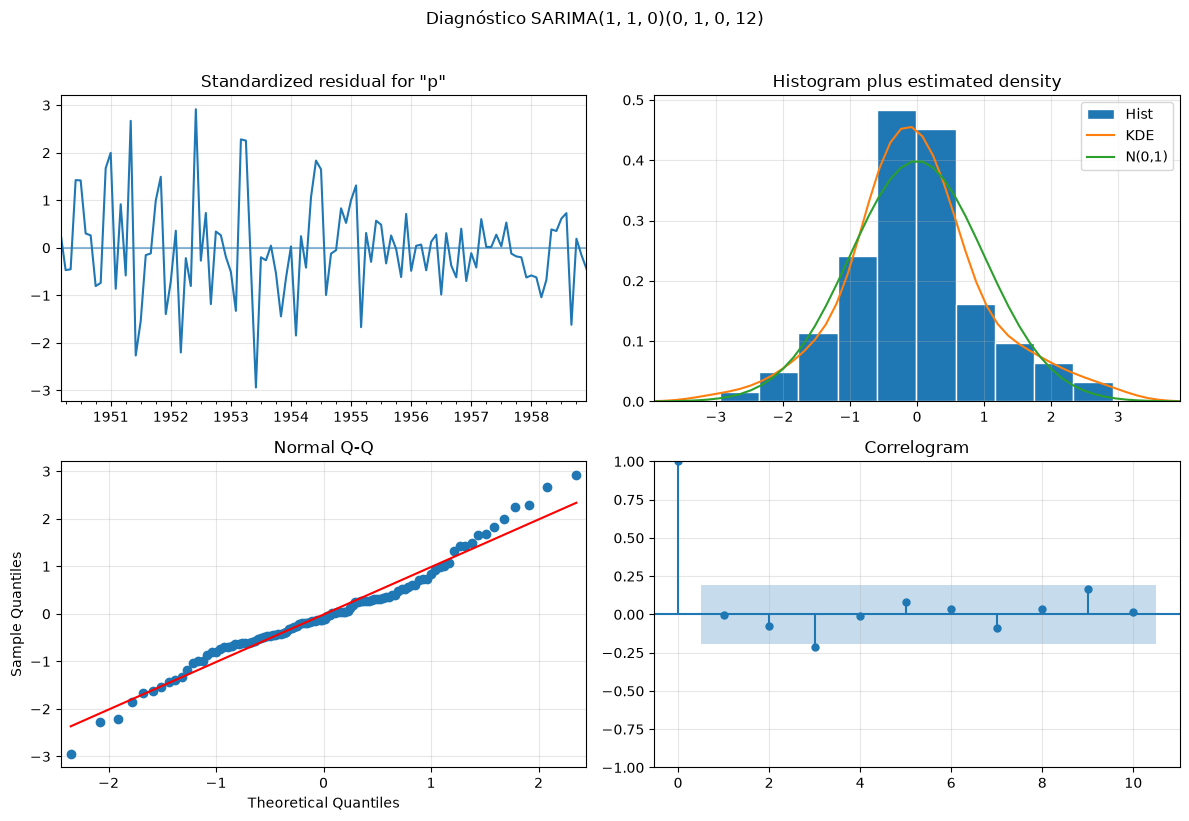

In [50]:
res_sarima = ajustar(best_sarima_order, best_sarima_sorder)
pred_sarima, mae, rmse, mape = evaluar(res_sarima)
nombre_sarima = f"SARIMA{best_sarima_order}{best_sarima_sorder}"
resultados[nombre_sarima] = dict(res=res_sarima, pred=pred_sarima, aic=res_sarima.aic, mae=mae, rmse=rmse, mape=mape)
print(f"AIC={res_sarima.aic:.2f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
fig = res_sarima.plot_diagnostics(figsize=(12, 8)); plt.suptitle(f"Diagnóstico {nombre_sarima}", y=1.02); plt.tight_layout(); plt.show()

## 7. Validación de los supuestos de los modelos

Un buen modelo deja residuos parecidos a **ruido blanco** (sin autocorrelación).
Lo verificamos con la prueba de **Ljung-Box**: si p > 0.05 no hay evidencia de
autocorrelación en los residuos (es lo deseable).

In [51]:
print(f"{'Modelo':<28}{'Ljung-Box p (lag 12)':>22}   Residuos")
print("-" * 70)
for nombre, d in resultados.items():
    lb = acorr_ljungbox(d["res"].resid[1:], lags=[12], return_df=True)
    pval = lb["lb_pvalue"].iloc[0]
    estado = "ruido blanco (ok)" if pval > 0.05 else "queda estructura"
    print(f"{nombre:<28}{pval:>22.4f}   {estado}")

Modelo                        Ljung-Box p (lag 12)   Residuos
----------------------------------------------------------------------
AR(2)                                       0.0000   queda estructura
MA(2)                                       0.0000   queda estructura
ARMA(2,2)                                   0.0002   queda estructura
ARIMA(3, 1, 3)                              0.2535   ruido blanco (ok)
SARIMA(1, 1, 0)(0, 1, 0, 12)                0.8466   ruido blanco (ok)


## 8. Comparación de todos los modelos

Comparamos por AIC (ajuste dentro de muestra) y por error fuera de muestra (MAE, RMSE, MAPE)
sobre los 24 meses de prueba.

In [52]:
tabla = pd.DataFrame({
    nombre: {"AIC": d["aic"], "MAE": d["mae"], "RMSE": d["rmse"], "MAPE(%)": d["mape"]}
    for nombre, d in resultados.items()
}).T.sort_values("RMSE")
tabla.round(3)

,AIC,MAE,RMSE,MAPE(%)
"ARIMA(3, 1, 3)",-218.826,44.549,61.015,9.002
"SARIMA(1, 1, 0)(0, 1, 0, 12)",-359.977,67.632,73.220,14.735
"ARMA(2,2)",-198.071,87.038,112.131,17.376
MA(2),-194.022,99.558,123.733,20.079
AR(2),-194.641,105.092,128.579,21.303


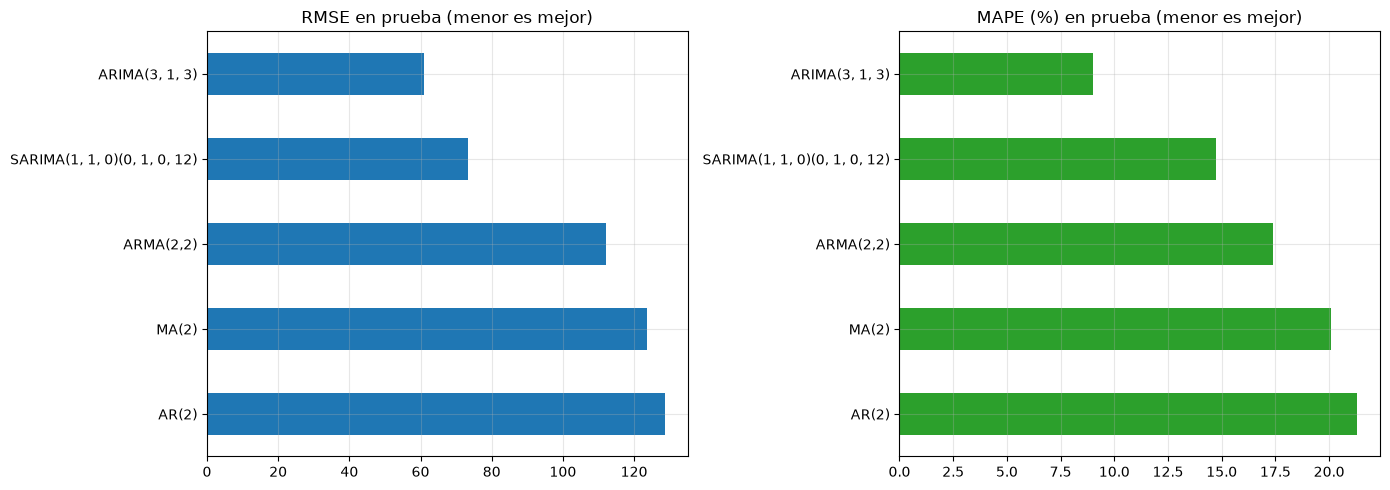

In [53]:
# Errores fuera de muestra por modelo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
tabla["RMSE"].plot(kind="barh", ax=ax[0], color="#1f77b4")
ax[0].set_title("RMSE en prueba (menor es mejor)"); ax[0].invert_yaxis()
tabla["MAPE(%)"].plot(kind="barh", ax=ax[1], color="#2ca02c")
ax[1].set_title("MAPE (%) en prueba (menor es mejor)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

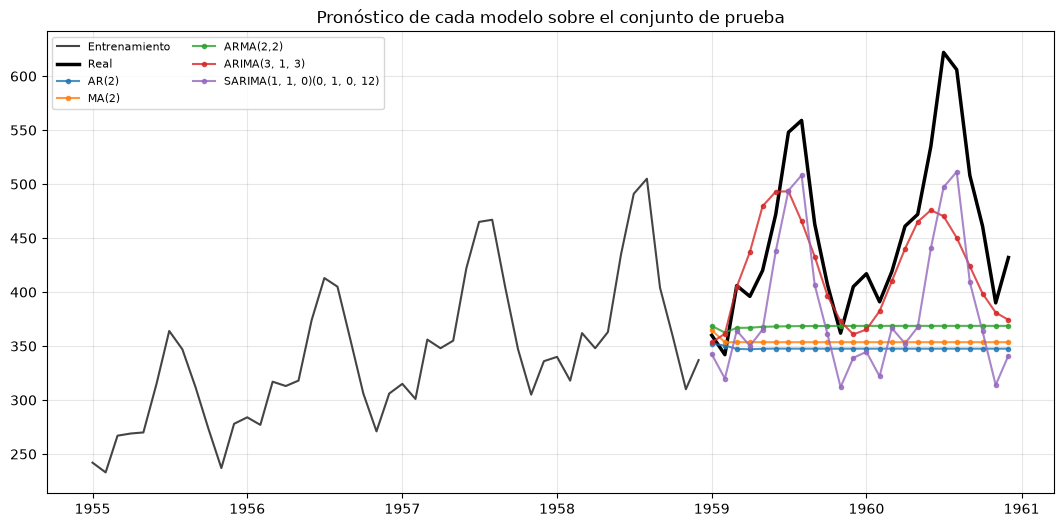

In [54]:
# Pronósticos de todos los modelos frente a los datos reales
plt.figure(figsize=(13, 6))
plt.plot(np.exp(train).iloc[-48:], label="Entrenamiento", color="#444")
plt.plot(test_orig, label="Real", color="black", linewidth=2.5)
for nombre, d in resultados.items():
    plt.plot(test_orig.index, d["pred"].values, marker=".", label=nombre, alpha=0.8)
plt.title("Pronóstico de cada modelo sobre el conjunto de prueba")
plt.legend(ncol=2, fontsize=8); plt.show()

## 9. Selección del mejor modelo

Elegimos el modelo con menor **RMSE** fuera de muestra (confirmado con MAPE y con residuos
que pasen Ljung-Box). En esta serie, con tendencia y estacionalidad marcadas, se espera que
gane **SARIMA**, porque es el único que modela explícitamente la estacionalidad.

In [55]:
mejor_nombre = tabla.index[0]
mejor_modelo = resultados[mejor_nombre]
print("Mejor modelo:", mejor_nombre)
print(tabla.loc[mejor_nombre].round(3).to_string())

Mejor modelo: ARIMA(3, 1, 3)
AIC       -218.826
MAE         44.549
RMSE        61.015
MAPE(%)      9.002


## 10. Validación walk-forward del mejor modelo

Simulamos el uso real: en cada paso reentrenamos con toda la historia disponible, predecimos
el siguiente mes, incorporamos el valor real y avanzamos. Es la validación más honesta para
series de tiempo.

Walk-forward  MAE=32.49  RMSE=40.91  MAPE=7.05%


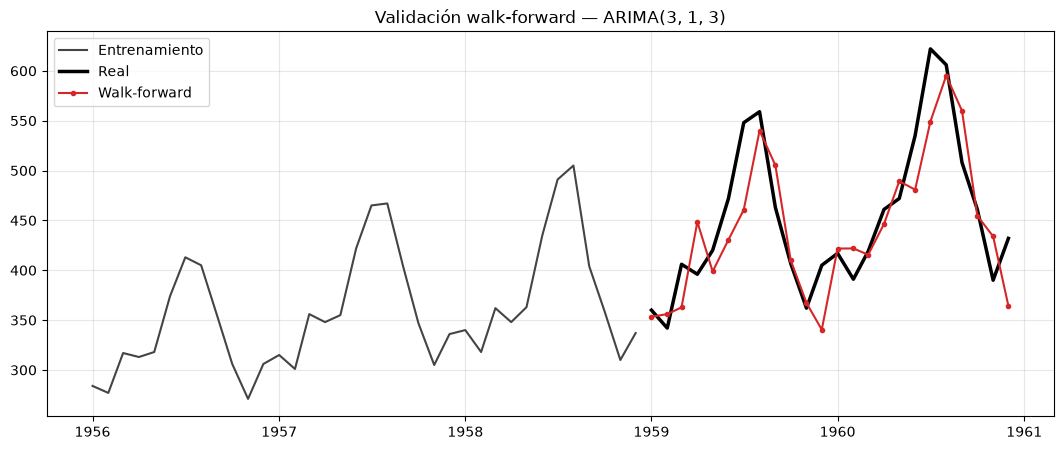

In [56]:
best_order = mejor_modelo["res"].model.order
best_sorder = mejor_modelo["res"].model.seasonal_order

historia = list(train.values)
wf_pred = []
for t in range(len(test)):
    m = SARIMAX(historia, order=best_order, seasonal_order=best_sorder,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    yhat = m.forecast(1)[0]
    wf_pred.append(np.exp(yhat))
    historia.append(test.iloc[t])   # incorporamos el valor real observado

wf_pred = pd.Series(wf_pred, index=test.index)
mae, rmse, mape = metricas(test_orig.values, wf_pred.values)
print(f"Walk-forward  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

plt.figure(figsize=(13, 5))
plt.plot(np.exp(train).iloc[-36:], label="Entrenamiento", color="#444")
plt.plot(test_orig, label="Real", color="black", linewidth=2.5)
plt.plot(wf_pred, label="Walk-forward", color="#d62728", marker=".")
plt.title(f"Validación walk-forward — {mejor_nombre}"); plt.legend(); plt.show()

## 11. Pronóstico final

Reentrenamos el mejor modelo con **toda** la serie y pronosticamos los próximos 24 meses,
con intervalos de confianza. Invertimos el logaritmo para volver a la escala original.

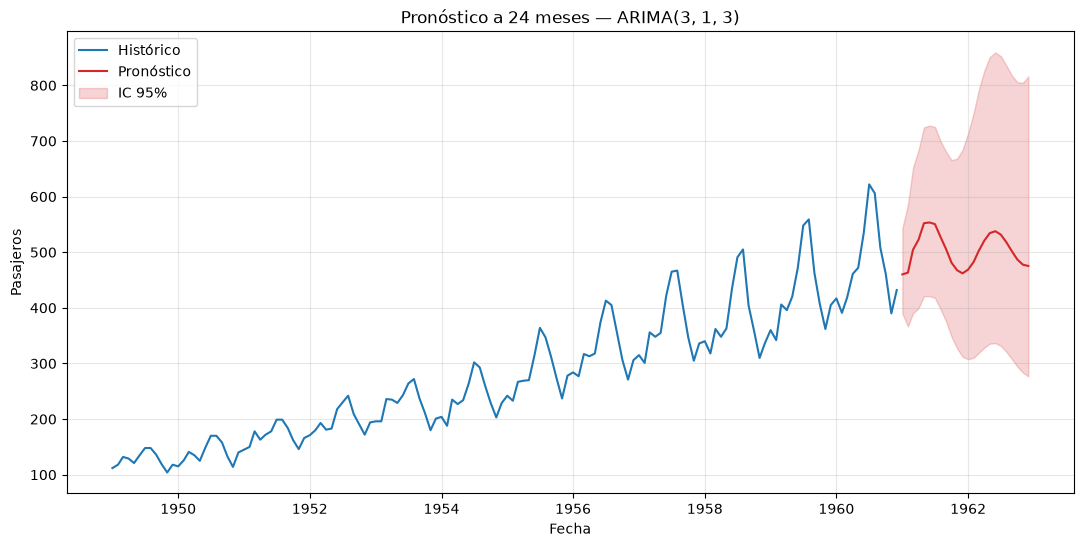

,pronostico
1961-01-01,460.1
1961-02-01,463.3
1961-03-01,504.3
1961-04-01,522.7
1961-05-01,552.2
1961-06-01,553.5
1961-07-01,550.5
1961-08-01,527.4
1961-09-01,505.4
1961-10-01,481.1


In [57]:
y_full = np.log(serie)
modelo_final = SARIMAX(y_full, order=best_order, seasonal_order=best_sorder,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

pasos = 24
fc = modelo_final.get_forecast(steps=pasos)
media = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int(alpha=0.05))

plt.figure(figsize=(13, 6))
plt.plot(serie, label="Histórico", color="#1f77b4")
plt.plot(media.index, media.values, label="Pronóstico", color="#d62728")
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#d62728", alpha=0.2, label="IC 95%")
plt.title(f"Pronóstico a {pasos} meses — {mejor_nombre}")
plt.xlabel("Fecha"); plt.ylabel("Pasajeros"); plt.legend(); plt.show()

media.round(1).to_frame("pronostico").head(12)

## 12. Conclusiones

- La serie *Air Passengers* tiene **tendencia** y **estacionalidad multiplicativa**; el logaritmo
  estabiliza la varianza y la diferenciación (d = 1, D = 1) la vuelve estacionaria.
- ADF y KPSS confirman la estacionariedad tras transformar; ACF/PACF y la búsqueda por AIC
  guían los órdenes p, q, P, Q.
- Construimos y validamos **AR, MA, ARMA, ARIMA y SARIMA**. Los modelos sin componente estacional
  (AR, MA, ARMA, ARIMA no estacional) no capturan el ciclo anual y cometen más error fuera de muestra.
- **SARIMA** es el mejor para este caso: menor RMSE/MAPE en prueba, residuos compatibles con ruido
  blanco (Ljung-Box) y buen desempeño en la validación walk-forward.
- Lección general: elige el modelo más simple que capture la estructura de los datos y valídalo
  siempre con datos posteriores en el tiempo, nunca barajados.